In [ ]:
# ---- Standard Library ----
import io
import random

# ---- Numerical / Data ----
import numpy as np
import pandas as pd

# ---- PyTorch ----
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# ---- PyTorch Geometric ----
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import (GINConv, GINEConv, global_add_pool, global_max_pool, global_mean_pool) 

# ---- Captum ----
from captum.attr import IntegratedGradients

# ---- Scikit-learn ----
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# ---- RDKit ----
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import (AllChem, Crippen, Descriptors, rdMolDescriptors,)
from rdkit.Chem.Draw import SimilarityMaps, rdMolDraw2D
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.Scaffolds import MurckoScaffold

# ---- Visualization ----
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from PIL import Image
from IPython.display import SVG, display

# ---- Dimensionality Reduction ----
import umap.umap_ as umap

# ---- Disable RDKit Warnings ----
RDLogger.DisableLog("rdApp.*")

In [ ]:
# ---- Load Data ----
raw = pd.read_csv(r"../csv/JAK2.csv", sep=";", low_memory=False)

In [ ]:
# ---- Exploratory Data Analysis ----
raw['Standard Type'].value_counts()

Standard Type
IC50                                    19301
k_off                                   14112
kon                                     14112
Ki                                       4644
Inhibition                               1943
Activity                                  733
Kd                                        491
Residual Activity                         316
EC50                                      313
% Control                                 108
Ratio IC50                                 45
INH                                        36
% of control                               27
GI50                                       26
Delta Tm                                   25
fIC50                                      13
% of inhibition                            12
Residual activity                           9
deltaH                                      7
deltaG                                      7
-TdeltaS                                    7
FC                  

In [ ]:
# ---- Filter IC50 Data ----
df = raw[raw['Standard Type']=='IC50'].copy()

In [ ]:
# ---- Dataset Info ----
print(f"The shape of the dataset is {df.shape}\n")
print(df.info())

The shape of the dataset is (19301, 48)

<class 'pandas.core.frame.DataFrame'>
Index: 19301 entries, 2 to 56316
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Molecule ChEMBL ID          19301 non-null  object 
 1   Molecule Name               625 non-null    object 
 2   Molecule Max Phase          593 non-null    float64
 3   Molecular Weight            19269 non-null  float64
 4   #RO5 Violations             19249 non-null  float64
 5   AlogP                       19249 non-null  float64
 6   Compound Key                19301 non-null  object 
 7   Smiles                      19269 non-null  object 
 8   Standard Type               19301 non-null  object 
 9   Standard Relation           19122 non-null  object 
 10  Standard Value              19122 non-null  float64
 11  Standard Units              19122 non-null  object 
 12  pChEMBL Value               14160 non-null  float64


In [ ]:
# ---- Data Cleaning & Units Filtering ----
print(df['Standard Units'].value_counts())
df = df[df['Standard Units']=='nM'].copy()

df.dropna(subset=['Smiles', 'Standard Units', 'Standard Relation', 'Standard Value'], inplace=True)
print(df.shape)
print(df.info())

Standard Units
nM         19089
10^2 uM        1
Name: count, dtype: int64
(19089, 48)
<class 'pandas.core.frame.DataFrame'>
Index: 19089 entries, 2 to 56316
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Molecule ChEMBL ID          19089 non-null  object 
 1   Molecule Name               620 non-null    object 
 2   Molecule Max Phase          588 non-null    float64
 3   Molecular Weight            19089 non-null  float64
 4   #RO5 Violations             19070 non-null  float64
 5   AlogP                       19070 non-null  float64
 6   Compound Key                19089 non-null  object 
 7   Smiles                      19089 non-null  object 
 8   Standard Type               19089 non-null  object 
 9   Standard Relation           19089 non-null  object 
 10  Standard Value              19089 non-null  float64
 11  Standard Units              19089 non-null  object 
 12  pChEMB

In [ ]:
# ---- Filter Exact Relations ----
df = df[df['Standard Relation']=="'='"].copy()
df.head()

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
2,CHEMBL1231124,AZD-1480,2.0,348.77,0.0,3.01,BDBM294911,Cc1cc(Nc2nc(N[C@@H](C)c3ncc(F)cn3)ncc2Cl)[nH]n1,IC50,'=',...,CHEMBL5725835,37,BindingDB Patent Bioactivity Data,NaN,2018.0,NaN,NaN,NaN,NaN,0.700
3,CHEMBL2206059,NaN,NaN,359.46,0.0,2.32,BDBM50402074,CS(=O)(=O)NCc1nc2cnc3[nH]ccc3c2n1[C@@H]1C[C@H]...,IC50,'=',...,CHEMBL5725835,37,BindingDB Patent Bioactivity Data,NaN,2018.0,NaN,NaN,NaN,NaN,190.000
39,CHEMBL5888413,NaN,NaN,381.46,0.0,2.02,BDBM270872,CNS(=O)(=O)C[C@H]1CC[C@H](N(C)c2c([N+](=O)[O-]...,IC50,'=',...,CHEMBL5725576,37,BindingDB Patent Bioactivity Data,NaN,2018.0,NaN,NaN,NaN,NaN,1200.000
40,CHEMBL3960213,NaN,NaN,361.41,0.0,2.57,BDBM228768,CN(C(=O)Nc1ccc(C#N)cc1)[C@@H]1CCN(c2ncnc3[nH]c...,IC50,'=',...,CHEMBL3886703,37,BindingDB Patent Bioactivity Data,NaN,2016.0,NaN,NaN,NaN,NaN,0.550
42,CHEMBL1650736,NaN,NaN,433.42,0.0,2.03,16e,COc1cc(Nc2nc(N[C@@H](C)c3ncc(F)cn3)nc(N3CCOCC3...,IC50,'=',...,CHEMBL1649076,1,Scientific Literature,J Med Chem,2011.0,NaN,NaN,NaN,NaN,0.008


In [ ]:
# ---- Select Relevant Columns ----
select_col = ['Smiles', 'Standard Value']
df = df[select_col]
df.head()

,Smiles,Standard Value
2,Cc1cc(Nc2nc(N[C@@H](C)c3ncc(F)cn3)ncc2Cl)[nH]n1,0.70
3,CS(=O)(=O)NCc1nc2cnc3[nH]ccc3c2n1[C@@H]1C[C@H]...,190.00
39,CNS(=O)(=O)C[C@H]1CC[C@H](N(C)c2c([N+](=O)[O-]...,1200.00
40,CN(C(=O)Nc1ccc(C#N)cc1)[C@@H]1CCN(c2ncnc3[nH]c...,0.55
42,COc1cc(Nc2nc(N[C@@H](C)c3ncc(F)cn3)nc(N3CCOCC3...,8.00


In [ ]:
# ---- Molecular Standardization Function ----
def standardize(smiles):

    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        return None

    clean_mol = rdMolStandardize.Cleanup(mol)

    parent_clean_mol = rdMolStandardize.FragmentParent(clean_mol)

    uncharger = rdMolStandardize.Uncharger() 
    uncharged_parent_clean_mol = uncharger.uncharge(parent_clean_mol)

    te = rdMolStandardize.TautomerEnumerator() 
    taut_uncharged_parent_clean_mol = te.Canonicalize(uncharged_parent_clean_mol)

    return Chem.MolToSmiles(taut_uncharged_parent_clean_mol)

# df["Standardized Smiles"] = df["Smiles"].apply(standardize)

In [ ]:
# df.to_csv(r"data/JAK2_clean.csv", index=False)

# From Here

In [ ]:
# df = pd.read_csv("..\BACE1_Predictive_Modeling\BACE1_cleaned.csv")

In [ ]:
# ---- Feature Engineering: Fingerprints & Molecular Descriptors ----
df = pd.read_csv(r"data/JAK2_clean.csv")
# select_col = ['Smiles', 'Standard Value', 'Standardized Smiles', 'pIC50']
# df = df[select_col]

def fp_scaffold(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return {
            "inchi_key": None,
            "scaffold": None,
            "MolWt": None,
            "NumHDonors": None,
            "NumHAcceptors": None,
            "TPSA": None,
            "NumRotatableBonds": None,
            "NumAromaticRings": None,
            "logP": None,
            "fp": None,
        }

    # Fingerprint
    fp_rdkit = AllChem.GetMorganFingerprintAsBitVect(
        mol, radius=2, nBits=2048
    )
    fp_numpy = np.zeros((2048,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp_rdkit, fp_numpy)

    # Scaffold
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    scaffold_smiles = Chem.MolToSmiles(scaffold)

    return {
            "inchi_key": Chem.MolToInchiKey(mol),
            "scaffold": scaffold_smiles,
            "MolWt": Descriptors.ExactMolWt(mol),
            "NumHDonors": rdMolDescriptors.CalcNumHBD(mol),
            "NumHAcceptors": rdMolDescriptors.CalcNumHBA(mol),
            "TPSA": rdMolDescriptors.CalcTPSA(mol),
            "NumRotatableBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
            "NumAromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
            "logP": Crippen.MolLogP(mol),
            "fp": fp_numpy,
        }
props = df["Standardized Smiles"].apply(fp_scaffold).apply(pd.Series)

df = pd.concat([df, props], axis=1)

df.rename(columns={'Standard Value': 'IC50'}, inplace=True)
df['pIC50'] = 9 - np.log10(df['IC50'].astype(float))

c:\Users\yashd\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# ---- Remove Duplicate InChI Keys ----
def remove_dupli_inchi(df_bak, dupli_inchis):
    
    dupli_inchi_bak = df_bak["inchi_key"].value_counts() != 1

    dupli_inchis = (df_bak["inchi_key"].value_counts())[dupli_inchi_bak].index

    for inchi in dupli_inchis:
        median_value = df_bak[df_bak["inchi_key"] == inchi]["IC50"].median()
        index = df_bak[df_bak["inchi_key"] == inchi].index[0]
        single_input = df_bak[df_bak["inchi_key"] == inchi].loc[[index]]
        single_input["inchi_key"] = median_value
        
        df_bak.drop(index=df_bak[df_bak["inchi_key"] == inchi].index, inplace=True)
        df_bak = pd.concat([df_bak, single_input], ignore_index=True)
    return df_bak.reset_index(drop=True)

dupli_inchi = df["inchi_key"].value_counts() != 1
dupli_inchis = (df["inchi_key"].value_counts())[dupli_inchi].index

df = remove_dupli_inchi(df, dupli_inchis)
len(df)

10314

In [ ]:
# ---- Dataset Summary ----
df.describe()

,IC50,MolWt,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,NumAromaticRings,logP,pIC50
count,1.031400e+04,10314.000000,10314.000000,10314.000000,10314.000000,10314.000000,10314.000000,10314.000000,1.031400e+04
mean,1.909699e+04,442.987715,2.031414,6.314718,108.639529,5.626818,3.194493,3.211639,inf
std,2.676106e+05,85.071496,0.951037,1.807641,26.854111,1.999579,0.809610,1.139106,NaN
min,0.000000e+00,160.063663,0.000000,0.000000,6.480000,0.000000,0.000000,-4.738060,1.602060e+00
25%,1.100000e+01,386.174276,1.000000,5.000000,89.610000,4.000000,3.000000,2.439270,6.259637e+00
50%,6.400000e+01,435.230411,2.000000,6.000000,107.910000,6.000000,3.000000,3.177700,7.193820e+00
75%,5.500000e+02,492.167754,3.000000,7.000000,126.270000,7.000000,4.000000,3.934360,7.958607e+00
max,2.500000e+07,1517.647864,22.000000,21.000000,599.220000,25.000000,7.000000,10.139600,inf


In [ ]:
# ---- Filter Positive IC50 Values ----
df = df[df['IC50'] > 0.0].copy()
df.reset_index(drop=True, inplace=True)
df.shape

(10310, 14)

In [ ]:
# ---- Scaffold-Based Train/Test Split ----
scaffold_counts = (df['scaffold'].value_counts().reset_index())
scaffold_counts.columns = ['scaffold', 'count']

print(f'Length of the total unique scaffolds is {len(scaffold_counts)}')
target = len(df) * 0.7

cum_sum = scaffold_counts['count'].cumsum()
threshold = cum_sum.ge(target).idxmax()   

print(f"Threshold index: {threshold}")
print(f"Cumulative count: {cum_sum.iloc[threshold]}")

train_scaffold_list = scaffold_counts.iloc[:threshold+1]['scaffold'].tolist()
test_scaffold_list = scaffold_counts.iloc[threshold+1:]['scaffold'].tolist()

Length of the total unique scaffolds is 3853
Threshold index: 1035
Cumulative count: 7218


In [ ]:
# ---- Verify Split ----
print(len(df[df['scaffold'].isin(train_scaffold_list)]), len(df[df['scaffold'].isin(test_scaffold_list)]))

7218 3092


In [ ]:
# ---- Create Train/Test Datasets ----
train_scaffold = df[df['scaffold'].isin(train_scaffold_list)].reset_index(drop=True)
test_scaffold = df[df['scaffold'].isin(test_scaffold_list)].reset_index(drop=True)

train_dataset, test_dataset = train_test_split(df, test_size=0.3, shuffle=True, random_state=42)

train_dataset = train_dataset.reset_index(drop=True)
test_dataset = test_dataset.reset_index(drop=True)

len(train_dataset)

In [ ]:
# ---- UMAP Dimensionality Reduction ----
# Convert the 'fp' column containing feature vectors into a 2D matrix
X_fp = np.vstack(train_dataset['fp'].values)

# Create UMAP instance
umap_model = umap.UMAP(n_components=2, random_state=42)

# Fit and transform
X_fp_umap = umap_model.fit_transform(X_fp)

print(X_fp_umap.shape)

train_dataset['UMAP_1'] = X_fp_umap[:, 0]
train_dataset['UMAP_2'] = X_fp_umap[:, 1]

c:\Users\yashd\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(7217, 2)


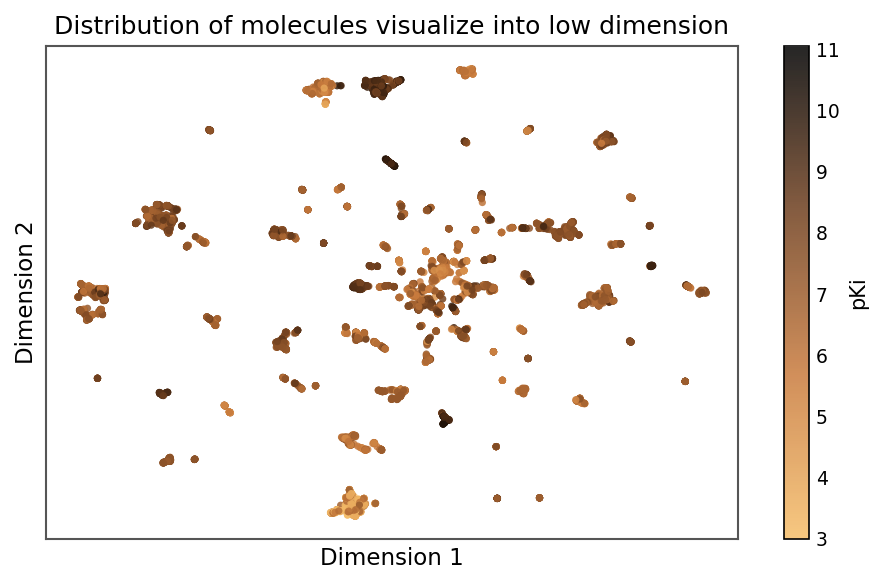

In [ ]:
# ---- Visualize Bioactivity Distribution with UMAP ----
paper_cmap = LinearSegmentedColormap.from_list("paper_orange_black",
                                                            [
                                                                "#F6BE6A",   # light orange
                                                                "#C97B3D",   # brown-orange
                                                                "#70401F",   # dark brown
                                                                "#000000"    # black
                                                            ])

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
scatter = ax.scatter( train_dataset['UMAP_1'], train_dataset['UMAP_2'], c=train_dataset['pIC50'], cmap=paper_cmap, s=12, alpha=0.85, edgecolors='none')

ax.set_xlabel("Dimension 1",fontsize=11)
ax.set_ylabel("Dimension 2", fontsize=11)
ax.tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

# Thin gray border
for spine in ax.spines.values():
    spine.set_color("#555555")
    spine.set_linewidth(1.0)
    
cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.06)
cbar.set_label("pKi", fontsize=10)
cbar.ax.tick_params(labelsize=9, length=0)
cbar.outline.set_linewidth(0.8)

plt.title("Distribution of molecules visualize into low dimension")
plt.tight_layout()
plt.savefig("plots/UMAP_Bioactivity_Projection.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ---- Extract Atom & Bond Features ----
def get_atom_bonds(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None
    mol = Chem.AddHs(mol)
    atoms = []
    for atm in mol.GetAtoms():
        atoms.append(np.array([ atm.GetAtomicNum() * 0.01,
                                atm.GetMass() * 0.01,
                                atm.GetDegree() * 0.01,
                                atm.GetFormalCharge(),
                                int(atm.GetIsAromatic()),
                                int(atm.GetNumRadicalElectrons())], dtype=np.float32))
    
    bonds = []  
    for bond in mol.GetBonds():
        bonds.append([bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()])
        bonds.append([bond.GetEndAtomIdx(), bond.GetBeginAtomIdx()])
        
    return np.array(atoms), np.array(bonds).transpose()

df[["atoms", "bonds"]] = df["Smiles"].apply(lambda x: pd.Series(get_atom_bonds(x)))
# test_dataset[["atoms", "bonds"]] = test_dataset["Smiles"].apply(lambda x: pd.Series(get_atom_bonds(x)))

In [ ]:
# ---- Dataset & Model Definitions ----
class GraphDataset(Dataset):
    def __init__(self, X, y, z, smiles):
        super().__init__()
        self.graphs = X.values
        self.targets = y.values.astype(float)
        self.fps = z
        self.smiles = smiles.values

    def len(self):
        return len(self.graphs)

    def get(self, idx):
        x = torch.tensor(self.graphs[idx][0], dtype=torch.float)
        edge_index = torch.tensor(self.graphs[idx][1], dtype=torch.long)
        # edge_attr = torch.tensor(self.graphs[idx][2], dtype=torch.float)

        fps = torch.tensor(self.fps[idx], dtype=torch.float)
        y = torch.tensor([self.targets[idx]], dtype=torch.float)

        # return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, fps=fps, y=y)
        return Data(x=x, edge_index=edge_index, fps=fps, y=y, smiles=str(self.smiles[idx])) 
    
# ---- Model class  ----
class GIN(nn.Module):
    def __init__(self, num_node_features, fp_dim=2048):
        super().__init__()

        self.conv1 = GINConv(nn.Sequential(nn.Linear(num_node_features, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Linear(64, 64)))
        self.conv2 = GINConv(nn.Sequential(nn.Linear(64, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Linear(64, 64)))
        self.conv3 = GINConv(nn.Sequential(nn.Linear(64, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Linear(128, 128)))
        self.conv4 = GINConv(nn.Sequential(nn.Linear(128, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Linear(256, 256)))

        self.mlp = nn.Sequential(
            nn.Linear(256 + fp_dim, 512), nn.ReLU(),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 1))

        self.fp_dim = fp_dim

    def forward(self, atom_num, edges_index, fp, batch):
        z = self.conv1(atom_num, edges_index)
        z = F.relu(z)
        z = self.conv2(z, edges_index)
        z = F.relu(z)
        z = self.conv3(z, edges_index)
        z = F.relu(z)
        z = self.conv4(z, edges_index)
        z = F.relu(z)

        z = global_max_pool(z, batch)

        fp = fp.view(z.size(0), self.fp_dim)
        z = torch.cat([z, fp], dim=1)
        z = self.mlp(z)

        return z
    
# ---- Eval function ----
def evaluate(model, loader, device, loss_fn):
    model.eval()
    total_loss = 0
    preds = []
    targets = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch.x, batch.edge_index, batch.fps, batch.batch)
            loss = loss_fn(pred.squeeze(), batch.y.squeeze())
            total_loss += loss.item()
            preds.extend(pred.squeeze().cpu().numpy())
            targets.extend(batch.y.squeeze().cpu().numpy())

    total_loss /= len(loader)
    preds = np.array(preds)
    targets = np.array(targets)

    r2 = r2_score(targets, preds)
    rmse = np.sqrt(mean_squared_error(targets, preds))

    return total_loss, preds, targets, r2, rmse

In [ ]:
# ---- Main GNN Pipeline Function ----
def run_gnn_pipeline(
    df,
    split_type="random",          # "scaffold" or "random"
    train_scaffold=None,          # required if split_type="scaffold"
    test_scaffold=None,           # required if split_type="scaffold"
    test_size=0.3,
    random_state=42,
    shuffle=True,
    atom_col="atoms",
    bond_col="bonds",
    target_col="pIC50",
    fp_col="fp",
    batch_size=256,
    num_node_features=6,
    fp_dim=2048,
    lr=1e-3,
    num_epochs=30,
    device=None,
    plot=True,
    verbose=True,
):
    def log(msg):
        if verbose:
            print(msg)

    # ---- Split ----
    log(f"[1/6] Splitting data using '{split_type}' strategy...")
    if split_type == "scaffold":
        if train_scaffold is None or test_scaffold is None:
            raise ValueError("train_scaffold and test_scaffold must be provided when split_type='scaffold'")
        train_dataset = df[df["scaffold"].isin(train_scaffold)].reset_index(drop=True)
        test_dataset = df[df["scaffold"].isin(test_scaffold)].reset_index(drop=True)
    elif split_type == "random":
        train_dataset, test_dataset = train_test_split(df, test_size=test_size, shuffle=shuffle, random_state=random_state)
        train_dataset = train_dataset.reset_index(drop=True)
        test_dataset = test_dataset.reset_index(drop=True)
    else:
        raise ValueError("split_type must be 'scaffold' or 'random'")
    log(f"      Train size: {len(train_dataset)} | Test size: {len(test_dataset)}")

    # ---- Datasets & loaders ----
    log("[2/6] Building PyG datasets and loaders...")
    # train_dataset_pyg = GraphDataset(train_dataset[[atom_col, bond_col]], train_dataset[target_col], train_dataset[fp_col], train_dataset['Standardized Smiles'])
    # test_dataset_pyg = GraphDataset(test_dataset[[atom_col, bond_col]], test_dataset[target_col], test_dataset[fp_col], test_dataset['Standardized Smiles'])
    
    train_dataset_pyg = GraphDataset(train_dataset[[atom_col, bond_col]], train_dataset[target_col], train_dataset[fp_col], train_dataset["Standardized Smiles"] )
    test_dataset_pyg = GraphDataset(test_dataset[[atom_col, bond_col]], test_dataset[target_col], test_dataset[fp_col], test_dataset["Standardized Smiles"] )

    train_loader = DataLoader(train_dataset_pyg, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset_pyg, batch_size=batch_size)
    log(f"      Batch size: {batch_size} | Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

    # ---- Model ----
    log("[3/6] Initializing model...")
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = GIN(num_node_features, fp_dim=fp_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()
    log(f"      Device: {device} | Node features: {num_node_features} | FP dim: {fp_dim} | LR: {lr}")

    # ---- Train ----
    log(f"[4/6] Training for {num_epochs} epochs...")
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0

        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            pred = model(batch.x, batch.edge_index, batch.fps, batch.batch,)
            loss = loss_fn(pred.squeeze(), batch.y.squeeze())
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        log(f"      Epoch {epoch+1:3d}/{num_epochs} | Loss: {train_loss:.4f}")

    # ---- Evaluate ----
    log("[5/6] Evaluating on train and test sets...")
    train_loss, train_preds, train_targets, train_r2, train_rmse = evaluate(model, train_loader, device, loss_fn)
    test_loss, test_preds, test_targets, test_r2, test_rmse = evaluate(model, test_loader, device, loss_fn)

    log(f"      Train Loss: {train_loss:.4f} | Train R²: {train_r2:.4f} | Train RMSE: {train_rmse:.4f}")
    log(f"      Test  Loss: {test_loss:.4f} | Test  R²: {test_r2:.4f} | Test  RMSE: {test_rmse:.4f}")

    # ---- Plot ----
    if plot:
        log("[6/6] Plotting predictions...")
        plot_predictions(
            train_targets, train_preds, train_r2,
            test_targets, test_preds, test_r2,
        )
    else:
        log("[6/6] Skipping plot (plot=False)")

    log("Pipeline complete.")

    return {
        "model": model,
        "train_loader": train_loader,
        "test_loader": test_loader,
        "train_dataset": train_dataset_pyg,
        "test_dataset": test_dataset_pyg,
        "train_loss": train_loss, "train_r2": train_r2, "train_rmse": train_rmse,
        "test_loss": test_loss, "test_r2": test_r2, "test_rmse": test_rmse,
        "train_preds": train_preds, "train_targets": train_targets,
        "test_preds": test_preds, "test_targets": test_targets,
    }

# ---- Plotting Function ----
def plot_predictions(
    train_targets, train_preds, train_r2,
    test_targets, test_preds, test_r2,
    figsize=(7, 7),
    train_color="tab:blue",
    test_color="tab:orange",
    ideal_color="r",
    alpha_train=0.5,
    alpha_test=0.4,
    title="Predicted vs Actual",
    xlabel="Actual pIC50",
    ylabel="Predicted pIC50",
):
    plt.figure(figsize=figsize)

    plt.scatter(train_targets, train_preds, alpha=alpha_train, color=train_color, label=f"Train (R²={train_r2:.3f})")
    plt.scatter(test_targets, test_preds, alpha=alpha_test, color=test_color, label=f"Test (R²={test_r2:.3f})")

    min_val = min(train_targets.min(), train_preds.min(), test_targets.min(), test_preds.min())
    max_val = max(train_targets.max(), train_preds.max(), test_targets.max(), test_preds.max())

    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color=ideal_color, linewidth=2, label='Ideal')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

[1/6] Splitting data using 'random' strategy...
      Train size: 7217 | Test size: 3093
[2/6] Building PyG datasets and loaders...
      Batch size: 256 | Train batches: 29 | Test batches: 13
[3/6] Initializing model...
      Device: cpu | Node features: 6 | FP dim: 2048 | LR: 0.001
[4/6] Training for 20 epochs...
      Epoch   1/20 | Loss: 11.7000
      Epoch   2/20 | Loss: 1.2972
      Epoch   3/20 | Loss: 0.9207
      Epoch   4/20 | Loss: 0.7512
      Epoch   5/20 | Loss: 0.6729
      Epoch   6/20 | Loss: 0.6450
      Epoch   7/20 | Loss: 0.5986
      Epoch   8/20 | Loss: 0.5879
      Epoch   9/20 | Loss: 0.5785
      Epoch  10/20 | Loss: 0.5410
      Epoch  11/20 | Loss: 0.5115
      Epoch  12/20 | Loss: 0.5140
      Epoch  13/20 | Loss: 0.5259
      Epoch  14/20 | Loss: 0.5127
      Epoch  15/20 | Loss: 0.4745
      Epoch  16/20 | Loss: 0.4816
      Epoch  17/20 | Loss: 0.4684
      Epoch  18/20 | Loss: 0.4441
      Epoch  19/20 | Loss: 0.4694
      Epoch  20/20 | Loss: 0.4485
[5

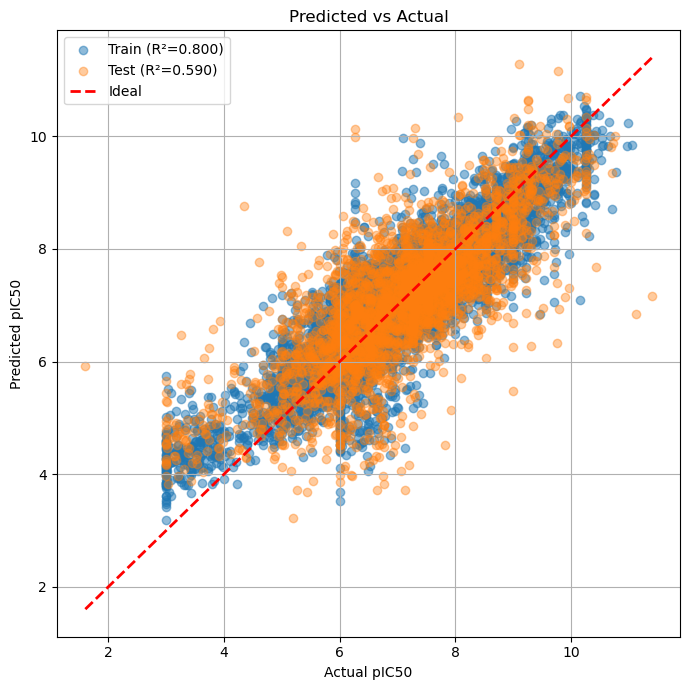

Pipeline complete.


In [ ]:
# ---- Random Split ----
random_results = run_gnn_pipeline(df, split_type="random", test_size=0.3, random_state=42, num_epochs=20)

[1/6] Splitting data using 'scaffold' strategy...
      Train size: 7218 | Test size: 3092
[2/6] Building PyG datasets and loaders...
      Batch size: 256 | Train batches: 29 | Test batches: 13
[3/6] Initializing model...
      Device: cpu | Node features: 6 | FP dim: 2048 | LR: 0.001
[4/6] Training for 20 epochs...
      Epoch   1/20 | Loss: 9.1785
      Epoch   2/20 | Loss: 1.1590
      Epoch   3/20 | Loss: 0.8117
      Epoch   4/20 | Loss: 0.6824
      Epoch   5/20 | Loss: 0.6456
      Epoch   6/20 | Loss: 0.5782
      Epoch   7/20 | Loss: 0.5652
      Epoch   8/20 | Loss: 0.5380
      Epoch   9/20 | Loss: 0.5319
      Epoch  10/20 | Loss: 0.5441
      Epoch  11/20 | Loss: 0.5121
      Epoch  12/20 | Loss: 0.5296
      Epoch  13/20 | Loss: 0.4839
      Epoch  14/20 | Loss: 0.4950
      Epoch  15/20 | Loss: 0.4756
      Epoch  16/20 | Loss: 0.4624
      Epoch  17/20 | Loss: 0.4616
      Epoch  18/20 | Loss: 0.4484
      Epoch  19/20 | Loss: 0.4399
      Epoch  20/20 | Loss: 0.4064
[

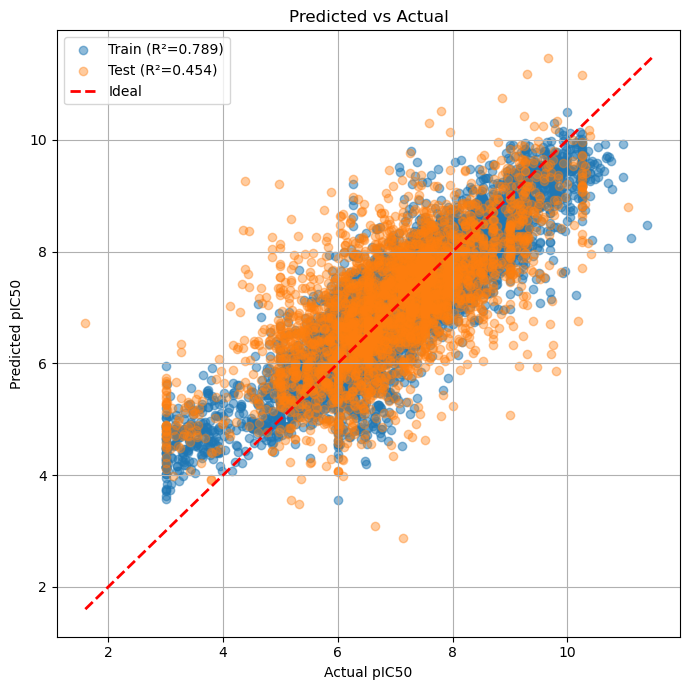

Pipeline complete.


In [ ]:
# ---- Scaffold Split ----
scaffold_results = run_gnn_pipeline(df, split_type="scaffold", train_scaffold=train_scaffold_list, test_scaffold=test_scaffold_list, num_epochs=20)

In [ ]:
# ---- Load Pre-trained Model ----
# torch.save(scaffold_results['model'].state_dict(), "models/gin_scaffold_model.pth")

model = GIN(num_node_features=15, fp_dim=2048)
model.load_state_dict(torch.load("models/gin_scaffold_model.pth", map_location="cpu"))
model.eval()

In [ ]:
# ---- XAI Utilities: Graph Wrapper & Attribution Helpers ----
class GraphWrapper(torch.nn.Module):
    def __init__(self, model, edge_index, n_nodes):
        super().__init__()
        self.model = model
        self.edge_index = edge_index   
        self.n_nodes = n_nodes         

    def forward(self, x, fp):
        total_nodes = x.shape[0]
        ratio = total_nodes // self.n_nodes 

        if ratio == 1:
            edge_index_batched = self.edge_index
            batch_idx = torch.zeros(self.n_nodes, dtype=torch.long, device=x.device)
        else:
            edge_index_batched = torch.cat([self.edge_index + i * self.n_nodes for i in range(ratio)], dim=1)
            batch_idx = torch.arange(ratio, device=x.device).repeat_interleave(self.n_nodes)

        return self.model(atom_num=x, edges_index=edge_index_batched, fp=fp, batch=batch_idx)

def get_top_fp_bits(attr_fp, fp_vec, top_k=15):
    """Return top-k contributing ON bits, sorted for a horizontal bar chart."""
    fp_scores = attr_fp.squeeze().detach().cpu().numpy()
    on_bits = np.nonzero(fp_vec)[0]
    if len(on_bits) == 0:
        return [], []
    on_scores = fp_scores[on_bits]
    order = np.argsort(-np.abs(on_scores))[:top_k]
    top_bits = on_bits[order]
    top_vals = on_scores[order]
    # sort ascending for a nicer horizontal bar chart (largest on top)
    sort_idx = np.argsort(top_vals)
    return top_bits[sort_idx], top_vals[sort_idx]

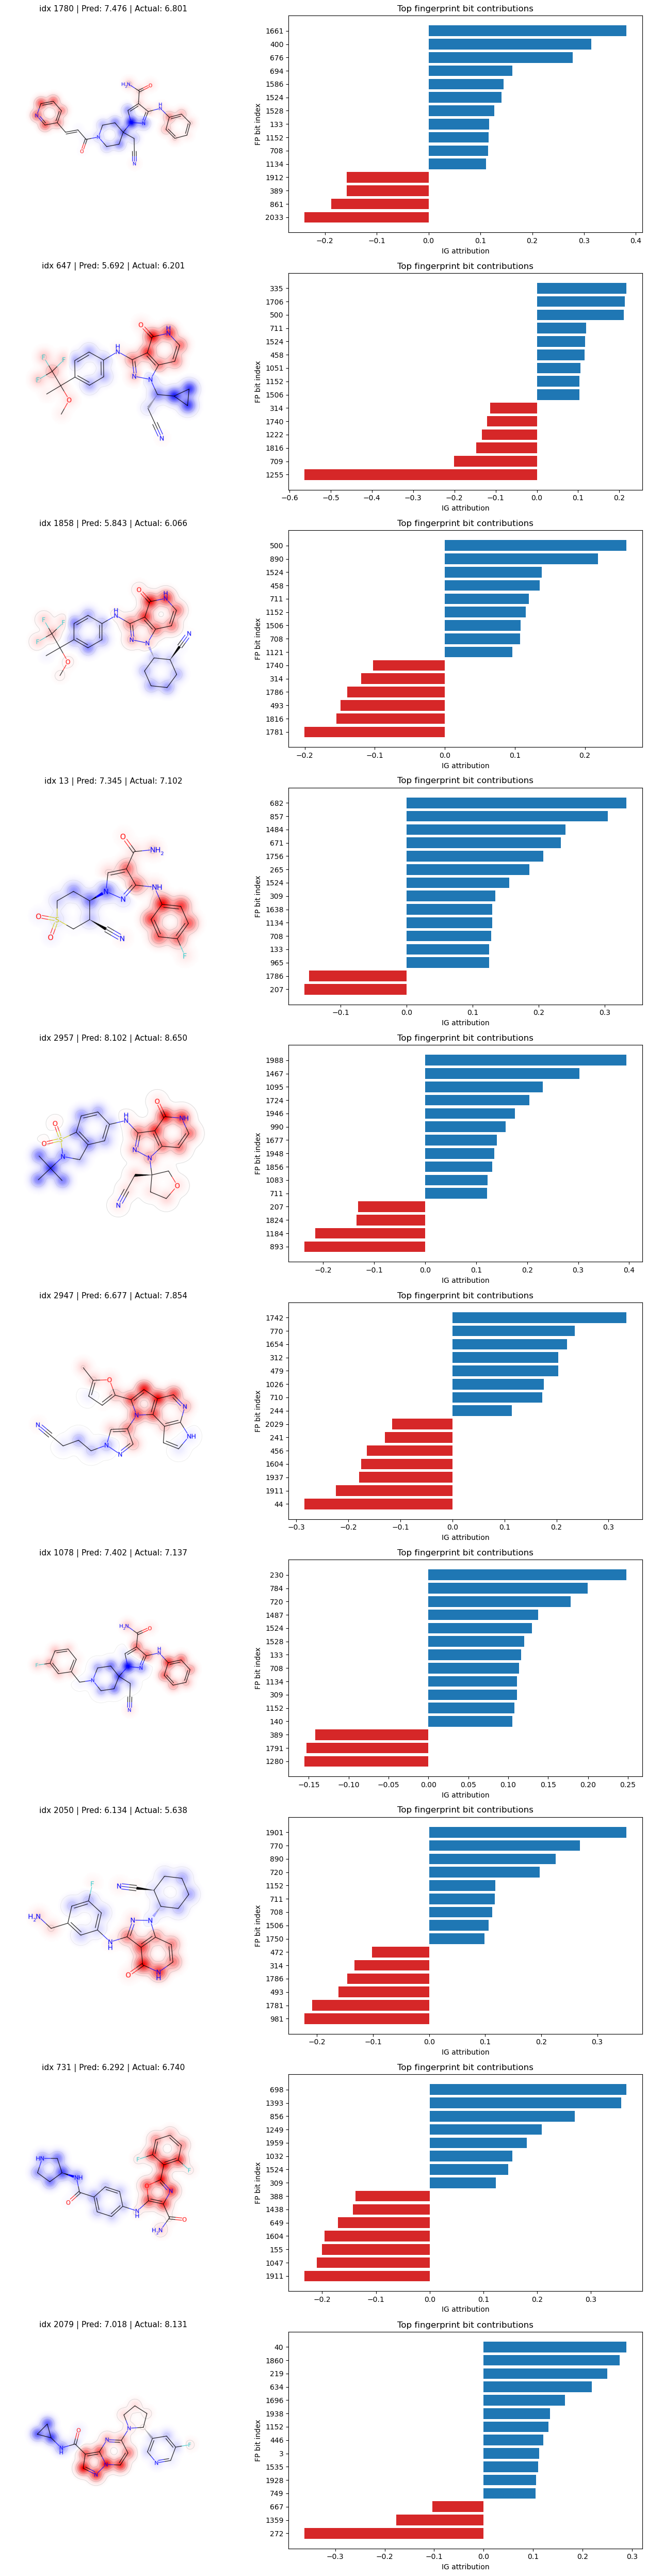

In [ ]:
# ---- Main loop ----
results = random_results  
model = results['model']
model.eval()

n_samples = 10
indices = random.sample(range(len(results["test_dataset"])), n_samples)

fig, axes = plt.subplots(n_samples, 2, figsize=(14, 5 * n_samples))

for row, idx in enumerate(indices):
    data = results["test_dataset"][idx]
    n_nodes = data.x.shape[0]

    x = data.x.clone().detach().requires_grad_(True)
    fp = data.fps.clone().detach().view(1, -1).requires_grad_(True)

    wrapper = GraphWrapper(model, data.edge_index, n_nodes)

    # prediction
    with torch.no_grad():
        pred = wrapper(data.x, data.fps.view(1, -1)).squeeze().item()
    actual = data.y.squeeze().item()

    # joint IG over (x, fp)
    ig = IntegratedGradients(wrapper)
    attr_x, attr_fp = ig.attribute(inputs=(x, fp), baselines=(torch.zeros_like(x), torch.zeros_like(fp)),n_steps=100)

    # ---- separate atom-level attribution ----
    atom_scores_signed = attr_x.sum(dim=1)
    mol_noH = Chem.MolFromSmiles(data.smiles)
    n_heavy = mol_noH.GetNumAtoms()

    weights_full = atom_scores_signed.detach().cpu().numpy().astype(float).tolist()
    weights_heavy = weights_full[:n_heavy]
    assert len(weights_heavy) == mol_noH.GetNumAtoms()

    drawer = rdMolDraw2D.MolDraw2DCairo(800, 800)
    drawer.drawOptions().bondLineWidth = 2
    SimilarityMaps.GetSimilarityMapFromWeights(mol_noH, weights_heavy, draw2d=drawer, colorMap="bwr")
    drawer.FinishDrawing()
    img = Image.open(io.BytesIO(drawer.GetDrawingText()))

    ax_mol = axes[row, 0]
    ax_mol.imshow(img)
    ax_mol.axis("off")
    ax_mol.set_title(f"idx {idx} | Pred: {pred:.3f} | Actual: {actual:.3f}", fontsize=11)

    # ---- separate fingerprint-level attribution ----
    fp_vec = data.fps.detach().cpu().numpy().flatten()
    top_bits, top_vals = get_top_fp_bits(attr_fp, fp_vec, top_k=15)

    ax_fp = axes[row, 1]
    if len(top_bits) > 0:
        colors = ["tab:blue" if v > 0 else "tab:red" for v in top_vals]
        ax_fp.barh([str(b) for b in top_bits], top_vals, color=colors)
        ax_fp.set_xlabel("IG attribution")
        ax_fp.set_ylabel("FP bit index")
        ax_fp.set_title("Top fingerprint bit contributions")
    else:
        ax_fp.text(0.5, 0.5, "No active FP bits", ha="center", va="center")
        ax_fp.axis("off")

plt.tight_layout()
# plt.savefig("attribution_grid_scaffold.png", dpi=150, bbox_inches="tight")
plt.show()